In [1]:
%matplotlib inline

In [2]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR_VECTOR = "simulation_wavefield_output_larger"  
PROJECT_DIR_TENSOR = "simulation_wavefield_output_moment_tensor_bigger"  
PROJECT_DIR_MOVING_SUBSUB = "simulation_wavefield_moving_source_momentt_subrayleigh" 
PROJECT_DIR_MOVING_SUB = "simulation_wavefield_moving_source_momentt_slight_subrayleigh" 
PROJECT_DIR_MOVING_MOMENTT = "simulation_wavefield_moving_source_momentt"
PROJECT_DIR_MOM_X = "simulation_wavefield_moving_source_moment_slight_subrayleigh_x"
PROJECT_DIR_VEC_X = "simulation_wavefield_moving_source_vector_slight_subrayleigh_x"
PROJECT_DIR_VEC_Y_NEG = "simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_neg"
PROJECT_DIR_VEC_Y_POS = "simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_pos"
PROJECT_DIR_VEC_BOTH = "simulation_wavefield_moving_source_vector_slight_subrayleigh_both"


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR_VECTOR not in contents:
        f.write(f"\n{PROJECT_DIR_VECTOR }/\n")
    if PROJECT_DIR_TENSOR not in contents:
        f.write(f"\n{PROJECT_DIR_TENSOR }/\n")
    if PROJECT_DIR_MOVING_SUBSUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUBSUB }/\n")
    if PROJECT_DIR_MOVING_SUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUB }/\n")
    if PROJECT_DIR_MOVING_MOMENTT not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_MOMENTT }/\n")
    if PROJECT_DIR_MOM_X not in contents:
        f.write(f"\n{PROJECT_DIR_MOM_X }/\n")
    if PROJECT_DIR_VEC_X not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_X }/\n")
    if PROJECT_DIR_VEC_Y_NEG not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_Y_NEG }/\n")
    if PROJECT_DIR_VEC_Y_POS not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_Y_POS }/\n")
    if PROJECT_DIR_VEC_BOTH not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_BOTH }/\n")    

import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.55 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p_v = sn.Project.from_domain(path=PROJECT_DIR_VECTOR, domain=domain_2d, load_if_exists=True)
p_t = sn.Project.from_domain(path=PROJECT_DIR_TENSOR, domain=domain_2d, load_if_exists=True)
p_moving_subsub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUBSUB, domain=domain_2d, load_if_exists=True)
p_moving_sub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUB, domain=domain_2d, load_if_exists=True)
p_moving_momentt = sn.Project.from_domain(path=PROJECT_DIR_MOVING_MOMENTT, domain=domain_2d, load_if_exists=True)
p_mom_x = sn.Project.from_domain(path=PROJECT_DIR_MOM_X, domain=domain_2d, load_if_exists=True)
p_vec_x = sn.Project.from_domain(path=PROJECT_DIR_VEC_X, domain=domain_2d, load_if_exists=True)
p_vec_y_neg = sn.Project.from_domain(path=PROJECT_DIR_VEC_Y_NEG, domain=domain_2d, load_if_exists=True)
p_vec_y_pos = sn.Project.from_domain(path=PROJECT_DIR_VEC_Y_POS, domain=domain_2d, load_if_exists=True)
p_vec_both = sn.Project.from_domain(path=PROJECT_DIR_VEC_BOTH, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-04-16 17:50:02,143] INFO: Loading project from simulation_wavefield_output_larger.


Accordion()

[2026-04-16 17:50:02,146] INFO: Loading project from simulation_wavefield_output_moment_tensor_bigger.


Accordion()

...

[2026-04-16 17:50:02,178] INFO: Loading project from simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_neg.


Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-16 17:50:02,188] INFO: Loading project from simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_pos.


Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-16 17:50:02,195] INFO: Loading project from simulation_wavefield_moving_source_vector_slight_subrayleigh_both.


In [4]:
# Extracting velocity wavefield data for moving-source event runs (vec_x vs mom_x)

def _get_first_available_event_output(project):
    """Return output directory for the first available moving-source event."""
    for i in range(500):
        sim_name = f"sim_2d_layered_moving_source_{i:03d}"
        event_name = f"event_wavefield_output_x{i:03d}"
        try:
            out_dir = project.simulations.get_simulation_output_directory(sim_name, event_name)
            vol_file = pathlib.Path(out_dir, "volume_data_output.h5")
            if vol_file.exists():
                return out_dir, sim_name, event_name
        except Exception:
            continue

    raise RuntimeError("No moving-source event output found (volume_data_output.h5 missing).")

# Vector-x project: use first available moving-source event output
out_2d_layered_v, sim_name_v, event_name_v = _get_first_available_event_output(p_vec_x)
vel_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(out_2d_layered_v, "volume_data_output.h5"),
    "velocity",
    "volume",
)

# Converting to an xarray
vel_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=[np.linspace(0, 300, 1001), np.linspace(0, 3, 101)],
)

# Moment-tensor-x project: use first available moving-source event output
out_2d_layered_t, sim_name_t, event_name_t = _get_first_available_event_output(p_mom_x)
vel_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(out_2d_layered_t, "volume_data_output.h5"),
    "velocity",
    "volume",
)

# Converting to an xarray
vel_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=[np.linspace(0, 300, 1001), np.linspace(0, 3, 101)],
)

print(f"Vector-x event used:  {sim_name_v} / {event_name_v}")
print(f"Moment-x event used:  {sim_name_t} / {event_name_t}")
print("Vector-x dims:", vel_2d_layered_v.dims)
print("Moment-x dims:", vel_2d_layered_t.dims)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/101101 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 5 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/50050 [00:00<?, ?it/s]

[2026-04-16 17:50:52,151] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 50050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Vector-x event used:  sim_2d_layered_moving_source_000 / event_wavefield_output_x000
Moment-x event used:  sim_2d_layered_moving_source_000 / event_wavefield_output_x000
Vector-x dims: ('t', 'c', 'x', 'y')
Moment-x dims: ('t', 'c', 'x', 'y')


In [5]:
# # Extracting moving-source wavefield output for all available moving-source events
# x_line_m = np.linspace(0.0, 300.0, 1001)
# y_surface_m = 3 * 2 / 3
# y_line_m = np.full_like(x_line_m, y_surface_m)

# # Keep the same moving-source x-grid as in moving_source.ipynb
# x_positions_m = np.arange(0.0, 300.0, 15.0)

# def extract_moving_receiver_section(project, x_positions):
#     """Extract vy along receiver line for all available moving-source events in one project."""
#     sections = []

#     for i, x_src in enumerate(x_positions):
#         sim_name = f"sim_2d_layered_moving_source_{i:03d}"
#         event_name = f"event_wavefield_output_x{i:03d}"

#         try:
#             out_dir = project.simulations.get_simulation_output_directory(sim_name, event_name)
#             vel_wo = wavefield_output.WavefieldOutput.from_file(
#                 pathlib.Path(out_dir, "volume_data_output.h5"),
#                 "velocity",
#                 "volume",
#             )
#         except Exception:
#             # Skip missing / failed events while still collecting all available outputs.
#             continue

#         vel_sg = wavefield_output.wavefield_output_to_xarray(
#             vel_wo,
#             points=np.column_stack((x_line_m, y_line_m)),
#         )
#         sg_vy = vel_sg.isel(c=1)
#         sg_vy = sg_vy.expand_dims(event_index=[float(x_src)])
#         sections.append(sg_vy)

#     if not sections:
#         raise ValueError("No moving-source wavefield outputs found for this project.")

#     return xr.concat(sections, dim="event_index")

# sg_moving_subsub = extract_moving_receiver_section(p_moving_subsub, x_positions_m)
# sg_moving_sub = extract_moving_receiver_section(p_moving_sub, x_positions_m)
# sg_moving_momentt = extract_moving_receiver_section(p_moving_momentt, x_positions_m)

# print("Loaded moving-source receiver sections:")
# print("  subrayleigh:", sg_moving_subsub.sizes)
# print("  slight_subrayleigh:", sg_moving_sub.sizes)
# print("  reference moving moment tensor:", sg_moving_momentt.sizes)

In [6]:
# # Plot moving-source waterfall sections (mean across all moving events per project)
# def prepare_mean_section(sg_events):
#     sg_mean = sg_events.mean(dim="event_index")
#     t_vals = sg_mean.t.values
#     data = sg_mean.values
#     vmax = np.percentile(np.abs(data), 95)
#     return t_vals, data, vmax

# t_subsub, data_subsub, vmax_subsub = prepare_mean_section(sg_moving_subsub)
# t_sub, data_sub, vmax_sub = prepare_mean_section(sg_moving_sub)
# t_momentt, data_momentt, vmax_momentt = prepare_mean_section(sg_moving_momentt)

# fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

# im0 = axes[0].pcolormesh(
#     x_line_m, t_subsub, data_subsub,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_subsub, vmax=vmax_subsub,
#  )
# axes[0].invert_yaxis()
# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 300)
# axes[0].set_title("Moving source - subrayleigh")
# for x_src in sg_moving_subsub.event_index.values:
#     axes[0].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im0, ax=axes[0], label="Vertical particle velocity (m/s)")

# im1 = axes[1].pcolormesh(
#     x_line_m, t_sub, data_sub,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_sub, vmax=vmax_sub,
#  )
# axes[1].set_xlabel("Distance (m)")
# axes[1].set_xlim(0, 300)
# axes[1].set_title("Moving source - slight subrayleigh")
# for x_src in sg_moving_sub.event_index.values:
#     axes[1].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im1, ax=axes[1], label="Vertical particle velocity (m/s)")

# im2 = axes[2].pcolormesh(
#     x_line_m, t_momentt, data_momentt,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_momentt, vmax=vmax_momentt,
#  )
# axes[2].set_xlabel("Distance (m)")
# axes[2].set_xlim(0, 300)
# axes[2].set_title("Moving source - reference moment tensor (supershear)")
# for x_src in sg_moving_momentt.event_index.values:
#     axes[2].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im2, ax=axes[2], label="Vertical particle velocity (m/s)")

# fig.suptitle(
#     "Moving-source receiver-line waterfall plots (mean over all moving events)",
#     y=1.03,
#     fontsize=12,
#  )
# plt.tight_layout()
# plt.show()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

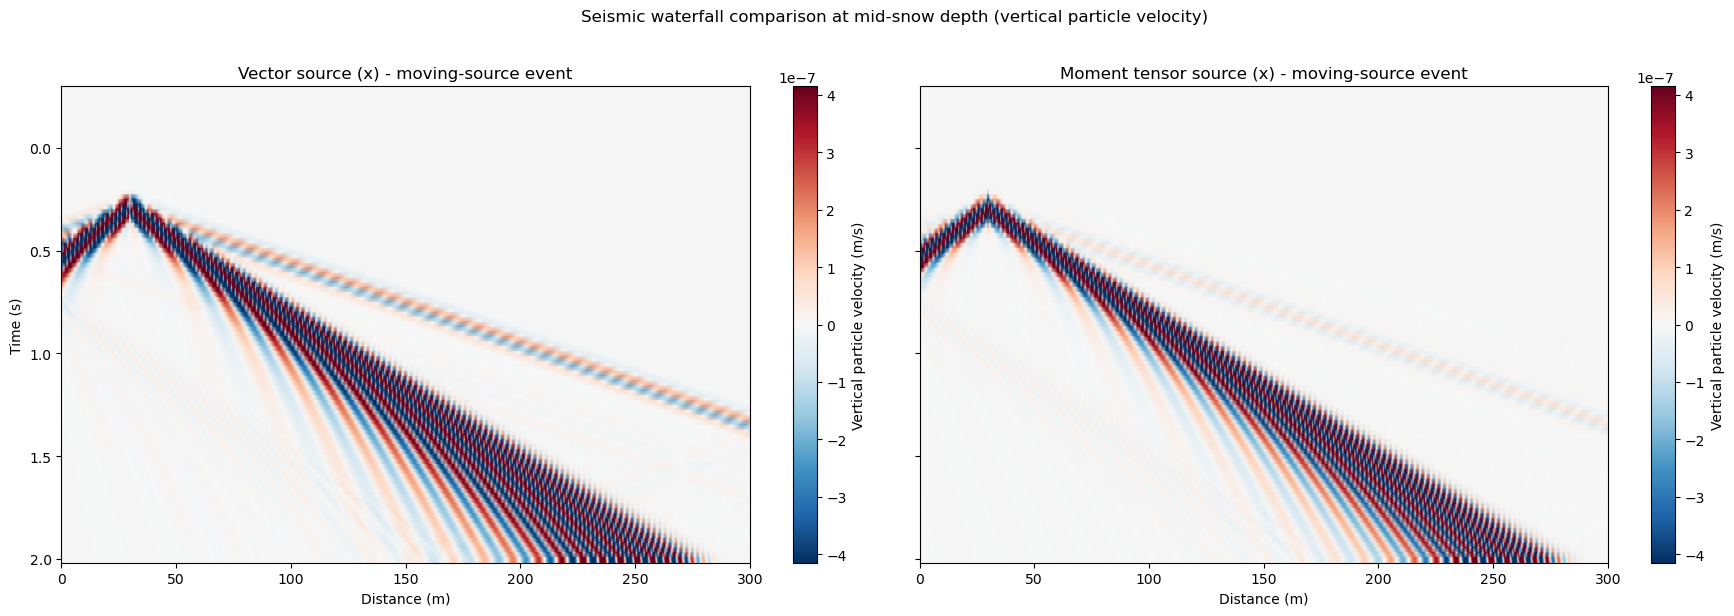

In [ ]:
# Plot moment-tensor and vector waterfall plots next to each other (event-based)

# Define receiver line at snow-earth interface
y_surface = 3 * 2 / 3  # middle of snow layer
x_line = np.linspace(0.0, 300.0, 1001)
y_line = np.full_like(x_line, y_surface)

# Extract wavefield along receiver line for vector source event
vel_sg_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_v = vel_sg_v.isel(c=1)
t_vals_v = sg_vy_v.t.values
data_v = sg_vy_v.values  # shape: (n_t, n_points)

# Extract wavefield along receiver line for moment tensor source event
vel_sg_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_t = vel_sg_t.isel(c=1)
t_vals_t = sg_vy_t.t.values
data_t = sg_vy_t.values  # shape: (n_t, n_points)

# Use a shared colorscale for direct visual comparison
vmax = np.percentile(np.abs([data_v, data_t]), 95)

# Create one figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

im_v = axes[0].pcolormesh(
    x_line, t_vals_v, data_v,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Vector source (positive x) - moving-source event")
fig.colorbar(im_v, ax=axes[0], label="Vertical particle velocity (m/s)")

im_t = axes[1].pcolormesh(
    x_line, t_vals_t, data_t,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
)
axes[1].set_xlabel("Distance (m)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Moment tensor source (postive x) - moving-source event")
fig.colorbar(im_t, ax=axes[1], label="Vertical particle velocity (m/s)")

fig.suptitle(
    "Seismic waterfall comparison at mid-snow depth (vertical particle velocity)",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [8]:
# # Frequency-domain comparison for vector and moment tensor sources

# # Extracting traces at x=0 m and same time window
# trace_v = vel_sg_v.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
# t_vals_v = trace_v.t.values
# y_vals_v = trace_v.values

# trace_t = vel_sg_t.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
# t_vals_t = trace_t.t.values
# y_vals_t = trace_t.values

# # dt and sampling frequency
# dt_v = float(np.diff(t_vals_v).mean())
# fs_v = 1.0 / dt_v

# dt_t = float(np.diff(t_vals_t).mean())
# fs_t = 1.0 / dt_t

# fig, axes = plt.subplots(3, 2, figsize=(16, 12))


# # Row 1: Raw seismograms ###################

# axes[0, 0].plot(t_vals_v, y_vals_v, lw=0.8, color="magenta")
# axes[0, 0].set_xlabel("Time (s)")
# axes[0, 0].set_ylabel("vy (m/s)")
# axes[0, 0].set_title("Seismogram (Vector) - x=0 m")
# axes[0, 0].axhline(0, color="gray", lw=0.5)

# axes[0, 1].plot(t_vals_t, y_vals_t, lw=0.8, color="purple")
# axes[0, 1].set_xlabel("Time (s)")
# axes[0, 1].set_ylabel("vy (m/s)")
# axes[0, 1].set_title("Seismogram (Moment tensor) - x=0 m")
# axes[0, 1].axhline(0, color="gray", lw=0.5)


# # Row 2: PSD (Welch) ##########################

# nperseg_v = min(1024, len(y_vals_v) // 4)
# freqs_psd_v, psd_v = signal.welch(
#     y_vals_v,
#     fs=fs_v,
#     nperseg=nperseg_v,
#     noverlap=nperseg_v // 2,
#     window="hann",      # reduces spectral leakage
#     scaling="density",  # units: (m/s)^2/Hz
# )
# axes[1, 0].semilogy(freqs_psd_v, psd_v, color="magenta")
# axes[1, 0].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
# axes[1, 0].set_xlabel("Frequency (Hz)")
# axes[1, 0].set_ylabel("PSD [(m/s)^2/Hz]")
# axes[1, 0].set_title("PSD (Welch) - Vector")
# axes[1, 0].set_xlim(0, fs_v / 2)
# axes[1, 0].legend()
# axes[1, 0].grid(True, which="both", alpha=0.3)

# nperseg_t = min(1024, len(y_vals_t) // 4)
# freqs_psd_t, psd_t = signal.welch(
#     y_vals_t,
#     fs=fs_t,
#     nperseg=nperseg_t,
#     noverlap=nperseg_t // 2,
#     window="hann",
#     scaling="density",
# )
# axes[1, 1].semilogy(freqs_psd_t, psd_t, color="purple")
# axes[1, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
# axes[1, 1].set_xlabel("Frequency (Hz)")
# axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
# axes[1, 1].set_title("PSD (Welch) - Moment tensor")
# axes[1, 1].set_xlim(0, fs_t / 2)
# axes[1, 1].legend()
# axes[1, 1].grid(True, which="both", alpha=0.3)


# # Row 3: Spectrograms (STFT) ######################

# nperseg_stft_v = min(512, len(y_vals_v) // 8)
# freqs_stft_v, t_stft_v, Sxx_v = signal.spectrogram(
#     y_vals_v,
#     fs=fs_v,
#     nperseg=nperseg_stft_v,
#     noverlap=nperseg_stft_v * 3 // 4,  # 75% overlap for smoother time axis
#     window="hann",
#     scaling="density",
# )
# Sxx_log_v = 10 * np.log10(Sxx_v + 1e-40)  # dB floor to avoid log(0)
# im_v = axes[2, 0].pcolormesh(
#     t_stft_v, freqs_stft_v, Sxx_log_v,
#     shading="gouraud",
#     cmap="magma",
# )
# axes[2, 0].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
# axes[2, 0].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
# axes[2, 0].set_xlabel("Time (s)")
# axes[2, 0].set_ylabel("Frequency (Hz)")
# axes[2, 0].set_title("Spectrogram (STFT) - Vector")
# axes[2, 0].set_ylim(0, min(100, fs_v / 2))
# axes[2, 0].legend(loc="upper right", fontsize=8)
# fig.colorbar(im_v, ax=axes[2, 0], label="Power [dB re (m/s)^2/Hz]")

# nperseg_stft_t = min(512, len(y_vals_t) // 8)
# freqs_stft_t, t_stft_t, Sxx_t = signal.spectrogram(
#     y_vals_t,
#     fs=fs_t,
#     nperseg=nperseg_stft_t,
#     noverlap=nperseg_stft_t * 3 // 4,
#     window="hann",
#     scaling="density",
# )
# Sxx_log_t = 10 * np.log10(Sxx_t + 1e-40)
# im_t = axes[2, 1].pcolormesh(
#     t_stft_t, freqs_stft_t, Sxx_log_t,
#     shading="gouraud",
#     cmap="magma",
# )
# axes[2, 1].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
# axes[2, 1].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
# axes[2, 1].set_xlabel("Time (s)")
# axes[2, 1].set_ylabel("Frequency (Hz)")
# axes[2, 1].set_title("Spectrogram (STFT) - Moment tensor")
# axes[2, 1].set_ylim(0, min(100, fs_t / 2))
# axes[2, 1].legend(loc="upper right", fontsize=8)
# fig.colorbar(im_t, ax=axes[2, 1], label="Power [dB re (m/s)^2/Hz]")

# plt.suptitle("Single-trace frequency analysis at x=0 m: Vector vs Moment tensor", fontsize=13)
# plt.tight_layout()
# plt.show()

In [9]:
# # Moving-source trace, PSD, and spectrogram plots for the three cases
# from IPython.display import display

# plt.rcParams["axes.formatter.use_mathtext"] = False
# plt.rcParams["text.usetex"] = False

# def select_moving_source_trace(data_array, representative_x=0.0, receiver_x=0.0):
#     source_dim = next((d for d in ["event_index", "event", "source"] if d in data_array.dims), None)
#     if source_dim is not None:
#         source_values = np.asarray(data_array[source_dim].values, dtype=float)
#         source_index = int(np.argmin(np.abs(source_values - representative_x)))
#         data_array = data_array.isel({source_dim: source_index})

#     receiver_dim = next((d for d in ["x", "point", "p0"] if d in data_array.dims), None)
#     if receiver_dim is None:
#         raise ValueError(f"Could not find receiver coordinate in dims={data_array.dims}")

#     trace = data_array.sel({receiver_dim: receiver_x}, method="nearest")
#     if "time" in trace.dims:
#         trace = trace.rename({"time": "t"})
#     return trace.sel(t=slice(-0.3, 2.0))

# def trace_psd_stft(trace):
#     t_vals = trace.t.values
#     y_vals = trace.values
#     dt = float(np.diff(t_vals).mean())
#     fs = 1.0 / dt

#     nperseg = min(1024, max(8, len(y_vals) // 4))
#     freqs_psd, psd = signal.welch(
#         y_vals,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=nperseg // 2,
#         window="hann",
#         scaling="density",
#     )

#     nperseg_stft = min(256, max(8, len(y_vals) // 16))
#     nperseg_stft = max(nperseg_stft, int(fs * 0.05))
#     freqs_stft, t_stft, Sxx = signal.spectrogram(
#         y_vals,
#         fs=fs,
#         nperseg=nperseg_stft,
#         noverlap=nperseg_stft * 15 // 16,
#         window="hann",
#         scaling="density",
#     )
#     t_stft = t_stft + t_vals[0]
#     Sxx_db = 10 * np.log10(Sxx + 1e-40)

#     return {
#         "t_vals": t_vals,
#         "y_vals": y_vals,
#         "fs": fs,
#         "freqs_psd": freqs_psd,
#         "psd": psd,
#         "freqs_stft": freqs_stft,
#         "t_stft": t_stft,
#         "Sxx_db": Sxx_db,
#     }

# case_specs = [
#     ("subrayleigh", sg_moving_subsub),
#     ("slight subrayleigh", sg_moving_sub),
#     ("reference moment tensor", sg_moving_momentt),
# ]

# case_results = []
# for case_label, case_data in case_specs:
#     trace = select_moving_source_trace(case_data, representative_x=0.0, receiver_x=0.0)
#     result = trace_psd_stft(trace)
#     result["case_label"] = case_label
#     case_results.append(result)

# trace_vmax = max(np.max(np.abs(item["y_vals"])) for item in case_results)
# psd_vmax = max(np.max(item["psd"]) for item in case_results)
# stft_vmax = max(np.max(item["Sxx_db"]) for item in case_results)
# stft_vmin = stft_vmax - 80

# fig, axes = plt.subplots(3, 3, figsize=(22, 13), constrained_layout=True)

# for col, item in enumerate(case_results):
#     axes[0, col].plot(item["t_vals"], item["y_vals"], lw=0.8, color="magenta")
#     axes[0, col].axhline(0, color="gray", lw=0.6)
#     axes[0, col].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8)
#     axes[0, col].set_xlabel("Time (s)")
#     axes[0, col].set_ylabel("vy (m/s)")
#     axes[0, col].set_title(f"Trace - {item['case_label']}")
#     axes[0, col].set_ylim(-trace_vmax, trace_vmax)

#     axes[1, col].semilogy(item["freqs_psd"], item["psd"], color="magenta", lw=1.0)
#     axes[1, col].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
#     axes[1, col].set_xlabel("Frequency (Hz)")
#     axes[1, col].set_ylabel("PSD [(m/s)^2/Hz]")
#     axes[1, col].set_title(f"PSD (Welch) - {item['case_label']}")
#     axes[1, col].set_xlim(0, min(100, item["fs"] / 2))
#     axes[1, col].set_ylim(max(np.min(item["psd"]) * 0.8, 1e-22), psd_vmax * 1.2)
#     axes[1, col].legend(fontsize=8)
#     axes[1, col].grid(True, which="both", alpha=0.3)

#     im = axes[2, col].pcolormesh(
#         item["t_stft"],
#         item["freqs_stft"],
#         item["Sxx_db"],
#         shading="auto",
#         cmap="magma",
#         vmin=stft_vmin,
#         vmax=stft_vmax,
#     )
#     axes[2, col].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8)
#     axes[2, col].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.8)
#     axes[2, col].set_xlabel("Time (s)")
#     axes[2, col].set_ylabel("Frequency (Hz)")
#     axes[2, col].set_title(f"Spectrogram - {item['case_label']}")
#     axes[2, col].set_ylim(0, min(100, item["fs"] / 2))
#     fig.colorbar(im, ax=axes[2, col], label="Power [dB re (m/s)^2/Hz]")

# fig.suptitle(
#     "Moving-source trace, PSD, and spectrogram comparison at receiver x=0 m",
#     fontsize=13,
# )
# display(fig)
# plt.close(fig)

In [ ]:
# # Force inline display in case backend was set to Agg earlier
# import matplotlib.pyplot as plt
# from IPython.display import display

# # Define receiver line 
# y_surface = 1.5 # This would be at snow-air boundary 

# # dis_2d_layered is already an xarray built from all events.
# # Use direct selection instead of calling wavefield_output_to_xarray again.
    
# # Resolve coordinate / dimension names robustly.
# coords_set = set(vel_2d_layered_vec_x.coords)
# dims_set = set(vel_2d_layered_vec_x.dims)

# x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
# y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
# t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
# c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
# e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

# if x_name is None or y_name is None or t_name is None or c_name is None:
#     raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# # Select both components at y receiver line
# sg_v_mom = vel_2d_layered_mom_x.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
# sg_v_vec = vel_2d_layered_vec_x.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# # Keep all moving-source events by reducing event dimension to a single stacked section.
# if e_name is not None and e_name in sg_vx.dims:
#     sg_v_mom_x = sg_v_mom_x.mean(dim=e_name)
#     sg_v_vec_x = sg_v_vec_x.mean(dim=e_name)
# else:
#     sg_v_mom_x = sg_v_mom_x
#     sg_v_vec_x = sg_v_vec_x

# # Ensure plotting order is (time, x)
# sg_v_mom_x = sg_v_mom_x.transpose(t_name, x_name)
# sg_v_vec_x = sg_v_vec_x.transpose(t_name, x_name)

# t_vals = sg_v_mom_x[t_name].values
# x_line = sg_v_mom_x[x_name].values
# data_v_mom_x = sg_v_mom_x.values
# data_v_vec_x = sg_v_vec_x.values

# print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
# print("t range:", t_vals[0], "->", t_vals[-1])
# print("vx shape:", data_v_mom_x.shape)
# print("vy shape:", data_v_vec_x.shape)

# # Clip colorscale (use same scale for both for comparison)
# vmax = np.percentile(np.abs([data_v_mom_x, data_v_vec_x]), 95)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Plot vx (horizontal component)
# im_vx = axes[0].pcolormesh(
#     x_line,
#     t_vals,
#     data_v_mom_x,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[0].invert_yaxis()

# # Mark all moving source positions
# # for x_src in x_positions:
# #     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 300)
# axes[0].set_title("Moment Tenosr source in positive x: Velocity(vx): horizontal component - receiver at snow-air interface")
# plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# # Plot vy (vertical component)
# im_vy = axes[1].pcolormesh(
#     x_line,
#     t_vals,
#     data_v_vec_x,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

# axes[1].set_xlabel("Distance (m)")
# axes[1].set_ylabel("Time (s)")
# axes[1].set_xlim(0, 300)
# axes[1].set_title("Vector source in positive x: Velocity(vx): horizontal component - receiver at snow-air interface")
# plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

# plt.tight_layout()

# # Display explicitly in notebook output
# display(fig)
# plt.close(fig)

NameError: name 'vel_2d_layered_vec_x' is not defined